## Linear Regression

**Y = wX + b**

Y --> Dependent Variable

X --> Independent Variable

w --> weight

b --> bias

## Gradient Descent

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

# Code implementation

Importing dependencies

In [138]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Classes in Python

Although this may seem scary to implement, go about it one function at a time.Using classes helps with keeping track of multiple models and makes your overall code tidier.

In [139]:
class Linear_Regression():


    def __init__(self, learning_rate, no_of_iterations):
        '''
        Constructor for the class
        Defines member variables learning_rate and no_of_iterations and initializes them to the value given while creating the object of the class
        They can be accessed in other functions of the class by using self.learning_rate and self.no_of_iterations
        '''

        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations


    ### TODO: fit function to train the model
    def fit(self, X, Y) :

        # TODO: store number of training examples and number of features in variables
        # shape[0] is the number of training examples and number of features in variables is shape[1]
        self.m , self.n = X.shape

        # TODO: initiate the weight and bias as zeros
        self.w = np.zeros(self.n)
        # each features will have different weight but each model can have only one bias
        self.b = 0

        self.X = X
        self.Y = Y

        # TODO: implement Gradient Descent for Optimization
        self.cost_history = []
        for i in range(self.no_of_iterations):

            cost = self.compute_cost()
            self.cost_history.append(cost)

            self.update_weights()

            if i % max(1, self.no_of_iterations // 10) == 0:
                print(f"Iteration {i:4}: Cost {cost:.2f}")





    ### TODO: function to update weights in gradient descent
    def update_weights(self) :

        Y_prediction = self.predict( self.X )

        # TODO: calculate gradients
        dw = (-2 * (self.X.T).dot(self.Y- Y_prediction))/self.m
        db = (-2 * np.sum(self.Y - Y_prediction))/self.m

        # TODO: update the weights
        
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    ### TODO: Line function for prediction:
    def predict(self, X) :
        return X.dot(self.w)+self.b
    
    def compute_cost(self):
        Y_prediction = self.predict(self.X)
        cost = np.mean((self.Y - Y_prediction) ** 2)
        return cost

## Data Pre-Processing

Here is the link to the dataset:

https://drive.google.com/file/d/1Q4CLe-ZaXS_IC3fhQwyhlLq0cWPvGsbB/view?usp=sharing

In [140]:
# loading the data from csv file to a pandas dataframe
salary_data = pd.read_csv('salary_data.csv')

In [141]:
# TODO: print the first 5 columns of the dataframe
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [142]:
# TODO: print the last 5 rows of the dataframe
salary_data.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [143]:
# TODO: print the number of rows & columns in the dataframe
row, column = salary_data.shape
print(row , column)

30 2


Splitting the feature and target:

In [144]:
X = salary_data.iloc[:,:-1].values
Y = salary_data.iloc[:,-1].values

In [145]:
X

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [146]:
Y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

Splitting the dataset into train and test datasets:

In [147]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state = 2)

## Training the linear regression model

Try experimenting with different learning rates and number of iterations.

In [148]:
LEARNING_RATE = 0.02 #@param
NO_OF_ITERATIONS = 1000 #@param

In [149]:
model = Linear_Regression(learning_rate = LEARNING_RATE, no_of_iterations=NO_OF_ITERATIONS)

In [150]:
model.fit(X_train, Y_train)

Iteration    0: Cost 6951848108.20
Iteration  100: Cost 41574325.60
Iteration  200: Cost 25701877.07
Iteration  300: Cost 22267635.10
Iteration  400: Cost 21524585.41
Iteration  500: Cost 21363815.48
Iteration  600: Cost 21329030.50
Iteration  700: Cost 21321504.25
Iteration  800: Cost 21319875.83
Iteration  900: Cost 21319523.50


In [151]:
# printing the parameter values ( weights & bias)

print('weight = ', model.w[0])
print('bias = ', model.b)

weight =  9514.400999035135
bias =  23697.406507136307


## Testing the model

In [152]:
test_data_prediction = model.predict(X_test)

In [153]:
test_data_prediction

array([ 36066.12780588,  34163.24760607,  66512.21100279,  58900.69020357,
        91249.65360029,  80783.81250135, 101715.49469922,  52240.60950424,
        42726.20850521,  88395.33330058])

Visualizing the predicted and actual values:

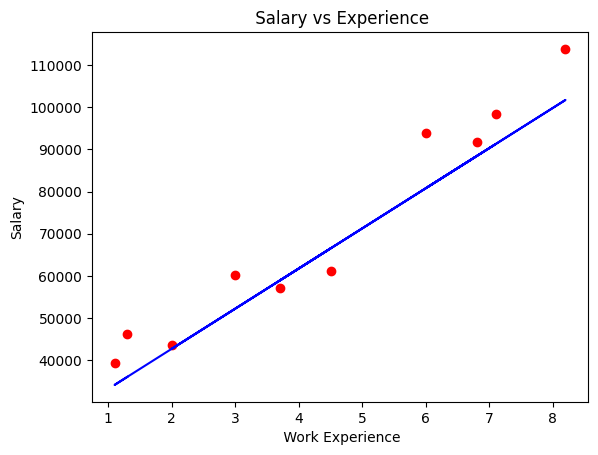

In [154]:
plt.scatter(X_test, Y_test, color = 'red')
plt.plot(X_test, test_data_prediction, color='blue')
plt.xlabel(' Work Experience')
plt.ylabel('Salary')
plt.title(' Salary vs Experience')
plt.show()